## Some Key EDA Findings

1. Class distribution: Outcome 0 accounts for approximately 65% of observations, while Outcome 1 accounts for approximately 35%.

2. Missing/invalid values: Several predictors contain zero values that may represent missing measurements, particularly Insulin (48.7%) and SkinThickness (29.6%).

3. Glucose: Outcome 1 observations generally have higher glucose values than Outcome 0 observations.

4. BMI: Outcome 1 observations tend to have higher BMI values, although substantial overlap exists.

5. Age: Age is positively skewed, with substantially more younger observations.

6. Insulin: Insulin has substantial dispersion and extreme values and will require further investigation during preprocessing.

7. Insulin: 51% of the Diabetic group (Outcome 1) has zero values while 47% of the Non-diabetic (Outcome 0) group has zero values

These findings will guide the data-cleaning and preprocessing decisions in the next stage.

### This is a remodel of the modelling notebook

## Models used for baseline
1. DummyClassifier: Serves as a sanity check for other models
2. LogisticRegression: Serves as a baseline to explore linear relationships
3. KNN: Useful for small datasets
4. SVC: To explore the non-linear boundaries
5. DecisionTreeClassifier: Tree-based Baseline for handling non-linear relationships
6. RandomForestClassifier: It is a more powerful tree-based model, less prone to overfitting

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('../data/diabetes.csv')

## Creating a Baseline Model

In [3]:
X = df.drop('Outcome', axis=1)
y = df.Outcome

In [4]:
np.random.seed(42)

# Stratification is used because the target variable is unbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
# Columns with encoded 0 missing values
zero_categories = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Remaining Columns
others_column = [col for col in X_train.columns if col not in zero_categories]

In [16]:
# Preprocessing steps
zero = Pipeline(steps=[
    ('impute', SimpleImputer(missing_values=0, strategy='median')),
    ('scaler', StandardScaler())
])
others = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessing = ColumnTransformer(transformers=[
    ('zero', zero, zero_categories),
    ('others', others, others_column)
])

preprocessing_without_scale = ColumnTransformer(transformers=[
    ('zero', zero, zero_categories)
])

In [19]:
models = {
    'dummy classifier': DummyClassifier(strategy='stratified'),
    'logistic regression': Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression())]),
    'KNN': Pipeline(steps=[('preprocesing', preprocessing), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'SVC': Pipeline(steps=[('preprocesing', preprocessing), ('model', SVC())]),
    'Decision Tree': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', DecisionTreeClassifier())]),
    'Random Forest': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', RandomForestClassifier(random_state=42))])
}

In [20]:
# Scoring metrics
scoring = {
    'accuracy': 'accuracy',
     "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
results = {}

for model, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        verbose=2
    )

    results[model] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.1s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


...

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.6s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished


[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    2.4s finished


In [26]:
results_df = pd.DataFrame(results).T

In [27]:
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
dummy classifier,0.563455,0.362128,0.335991,0.348286,0.508127
logistic regression,0.788231,0.763808,0.574751,0.654545,0.843364
KNN,0.729588,0.636708,0.565449,0.593861,0.784332
SVC,0.780128,0.741534,0.584164,0.648462,0.833308
Decision Tree,0.653139,0.504931,0.528018,0.515704,0.624009
Random Forest,0.742583,0.654168,0.560465,0.602945,0.778023


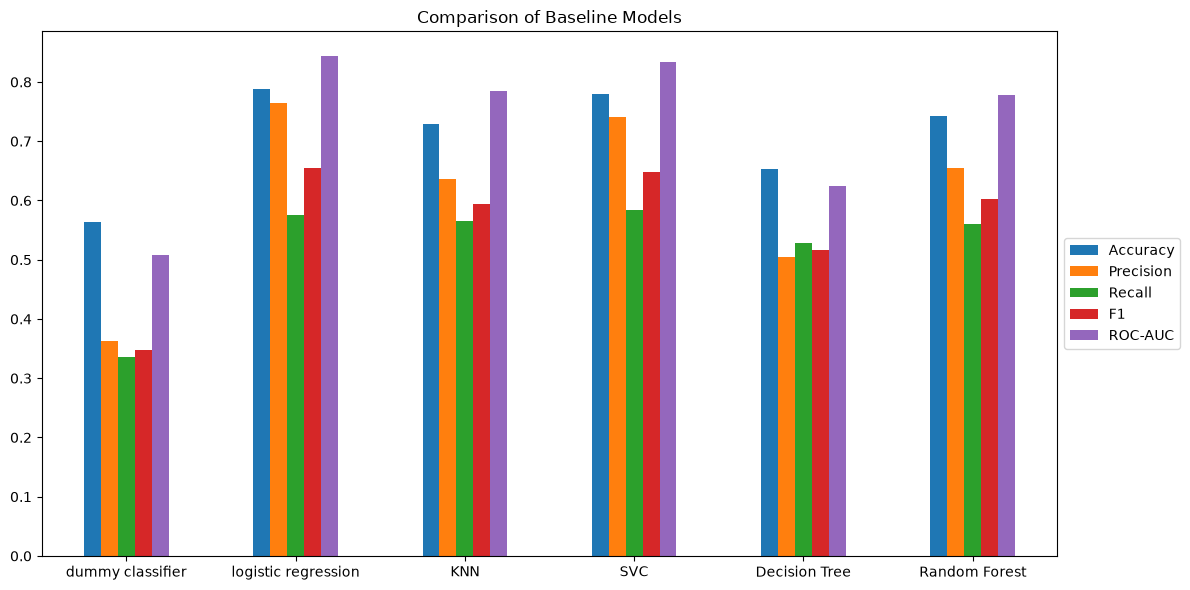

In [28]:
ax = results_df.plot.bar(
    title='Comparison of Baseline Models',
    figsize=(12, 6),
    rot=0
)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()